# Gottfried Wilhelm Leibniz Universität Hannover - Mapping

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS fak_name,
                        'Gottfried Wilhelm Leibniz Universität Hannover' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202601` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202601` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/0304hq317' -- 'Gottfried Wilhelm Leibniz Universität Hannover'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Gottfried Wilhelm Leibniz Universität Hannover,"L3S Research Center, Leibniz University, Hanov...",https://openalex.org/W4308081120
1,not assigned,Gottfried Wilhelm Leibniz Universität Hannover,"Leibniz University,L3S Research Center,Hanover...",https://openalex.org/W4308081120
2,not assigned,Gottfried Wilhelm Leibniz Universität Hannover,"Leibniz University Hannover,Institute of Formi...",https://openalex.org/W4312696141
3,not assigned,Gottfried Wilhelm Leibniz Universität Hannover,"L3S Research Center, Germany",https://openalex.org/W4224308764
4,not assigned,Gottfried Wilhelm Leibniz Universität Hannover,Leibniz Universität Hannover - Institute of E...,https://openalex.org/W4312493720


In [453]:
MAPPING_DICT = {
    'Exzellenzcluster PhoenixD': ['phoenixd'],
    'Fakultät für Architektur und Landschaft': ['environmental planning', 'archite(c|k)tur(?!es\sand\ssystem)(?!e\sand\ssystem)(?!e\sgroup)', 
                                                'raumentwicklung', 'umweltplanung', 'sustainable building systems', 'urban design',
                                                'open space planning', 'entwerfen und konstruieren'
                                               ],
    'Fakultät für Bauingenieurwesen und Geodäsie': ['bau(stoff|mechanik)', '(civil|coastal|digital) engineering', 'erdmessung',
                                                    'wind energy', 'risk( and| &|,| &amp;) reliability', 'bau(wesen|physik)',
                                                    'cartography', 'geo(information|technical|technik|informatik|detic|desy)', 
                                                    'steel', 'concrete','structural analysis', 'numerische mechanik',
                                                    '(computational|numerical) mechanics', 'waste', '(massiv|stahl)bau',
                                                    'building (physics|material)', 'hydrology', 'windenergiesysteme',
                                                    'statik und dynamik', 'risiko und zuverlässigkeit,', 
                                                    'photogrammetry', 'research training group', 'ludwig(-|\s)?franzius',
                                                    'siedlungswasserwirtschaft', 'construction management'
                                                   ],
    'Fakultät für Elektrotechnik und Informatik': ['drive systems', 'mic(ro|or)wave', '(electrical|software|systems|computer|high voltage) engineering',
                                                   'mi(k|c)roele(k|c)t(i|r)oni(sch|c)', 'electric power', 'knowledge(-|\s)based',
                                                   'information processing', 'devices', 'electrotechnology',
                                                   'computer science', 'artificial', 'informationsverarbeitung',
                                                   'regelungstechnik', 'of eecs', '(mensch|human)(-|\s)computer(-|\s)intera(k|c)tion',
                                                   'microeletronic', 'data science', '(theoretische|praktische) informatik',
                                                   'power electronics', 'software systems', 'power systems', 'communications',
                                                   'sensors and measurement', 'elektrotechnik', 'communication technology',
                                                   'kommunikationstechnik', 'health informatics', 'electrical energy',
                                                   'schering', 'antriebssysteme', 'natural language processing', 'automatic control',
                                                   'energy storage', 'electronic materials', 'bauelemente der elektronik',
                                                   'electronic und informatik'
                                                  ],
    'Fakultät für Maschinenbau': ['i(fw|wf)', 'thermo', 'continuum', 'assembly', 'plastic', 'turbomachinery', 'tribolog(ie|y)',
                                  'forming', 'product(ion)? (technology|engineering|development)', 'mecha(n)?troni(sche|c)(s)? system(e|s)', 
                                  'transport', 'multiphase processes', 'fabrikanlagen', 'institute of materials', 'systems and logistics',
                                  'reactive flows', 'vibration', 'technische verbrennung', 'kontinuumsmechanik', 'for material(s)? science',
                                  '(mikroproduktions|umform|kraftwerks)technik', '(mechanical|plant) engineering', 'werkzeugmaschinen', 
                                  'berufswissenschaften der metalltechnik', 'combustion', 'werkstoffkunde', 'produktentwicklung',
                                  'maschinenbau', 'control technology'
                                 ],
    'Fakultät für Mathematik und Physik': ['(applied|angewandte)(,)? math', 'institut(e)? (of|für) photoni(cs|k)', 
                                           '(theoretische|theoretical) physi(k|c)', '(q|o)uantum\s?optic', 
                                           'solid(‐|\s|-)state physi(s)?cs', 'gravitation(s|al)\s?physi(k|cs)',
                                           'geometry', '(department|faculty|institut(e)?) (of|for) mathematics', 'mathematik und physik', 'finanzmathematik',
                                           'differentialgeometrie', 'quantenoptik', 'algebra', 'festkörperphysik', 'solar',
                                           'mete(or|r)olog(ie|y)', 'institut(e)? (für|of|for) analysis', '(fakultät|faculty) (für|of) mathemati(k|cs)',
                                           'radiation', 'radioökologie', 'financial mathematics', 'computational science',
                                           'didacti(k|cs) (der|of) mathemati(k|cs)', 'mathematisches institut'
                                          ],
    'Forschungsstelle für Gesundheitsökonomie': ['center for health', '(cherh)'],
    'Forschungszentrum Küste (FZK)': ['coastal research cent(er|re)', 'forschungszentrum k(ü|u)ste'],
    'Forschungszentrum L3S': ['l3s'],
    'Hannoversches Zentrum für Optische Technologien (HOT)': ['hannover centre for optical technologies', 'optical', 'optische technologien'],
    'House of Insurance (HoI)': ['house of insurance'],
    'Juristische Fakultät': ['institute for political', 'intellectual', 'faculty of law', 'rechts(informatik|wissenschaften)', 'bürgerliches recht', 
                             '(zivil|handels|straf)recht', 'juristische(n)? fakultät', 'legal informatics'
                            ],
    'Laboratorium für Nano- und Quantenengineering (LNQE)': ['nano(-|‐)? and quantum', '(lnqe)', 'quantenengineering', 'schneiderberg 39'],
    'Leibniz Forschungszentrum FZ:GEO': ['fz:geo'],
    'Leibniz Forschungszentrum Inclusive Citizenship (CINC)': ['inclusive citizenship'],
    'Leibniz Forschungszentrum Wissenschaft und Gesellschaft (LCSS)': ['(lcss)'],
    'Leibniz School of Education': ['school of education'],
    #'Leibniz School of Optics & Photonics': [],
    #'LiFE 2050 - Leibniz Forschungszentrum Energie 2050': [],
    #'Mechatronik-Zentrum Hannover (MZH)': [],
    'Naturwissenschaftliche Fakultät': ['cell(?!s)', 'earth', 'production systems(?!\sand logistic)', 
                                        '(food|organic|technical|coordination|theoretical) chemistry', 
                                        'inorganic', 'electrochemistry', 'horticultural', 'pflanz(en)?genetik',
                                        'plant genetics', 'nutrition', 'erdsystemwissenschaften', 'botan(ik|y)', 
                                        '((un)?organische|technische|theoretische) chemie', 'mi(k|c)robiolog(ie|y)', 'food and one health',
                                        'naturwissenschaften', 'soil', 'landscape ecology', 'elektrochemie', 'mineralog(ie|y)',
                                        'geo(graphy|log(ie|y)|physics)', 'department of chemistry', 'lebensmittel(wissenschaft|chemie)', 'gartenbau', 
                                        'natural sciences', 'science education', 'koordinationschemie', '(physical|medicinal) chemistry',
                                        'bio(statistics|physics)', 'am kleinen felde 30', 'naturwissenschaftliche fakultät', 'kulturgeographie',
                                        'plant genetic', 'bodenkunde', 'propagat physiol'
                                       ],
    'Philosophische Fakultät': ['(special|empirical) education', 'so(c|z)iolog(ie|y)', '(historisches|deutsches) seminar', 'humanities', 
                                'language therapy', 'of political science' , 'life sciences', 'psychology', '(sonder|berufs)pädagogik',
                                '(department|institute) of (education|philosphy|theology)', '(politik|sport)wissenschaft', 'sport(s)? science', 
                                'historical institute', 'theologie', 'linguistics', 'philosoph(ie|y)', 'ethics and law',
                                'didaktik der (demokratie|geschichte)', 'englis(c)?h', 'adult education', 'department of history', 'religion',
                                'erziehungswis(-)?senschaft'
                               ],
    'QUEST-Leibniz-Forschungsschule': ['quest'],
    'TRUST Räumliche Transformation - Zukunft für Stadt und Land': ['trust—transdisciplinary'],
    'Wirtschaftswissenschaftliche Fakultät': ['wirtschafts(informatik|politik)', 'taxation', 'world trade', 'institute of health',
                                              'marketing', 'banking', 'institute of (statistics|probability)', 'economics (and management|department)',
                                              'labo(u)?r economics', 'human resource management', 'agricultural', 'personal und arbeit',
                                              'welthandel', 'risk and insurance', 'macroeconomic', 'economic policy', 'for health economics',
                                              'employment studies', 'managerial accounting', '(institut(e)?|department) (of|for) economics', 
                                              'innovation (research|management)', 'arbeitsökonomik', 'management (und|and) organi(s|z)ation',
                                              'wirtschaftswissenschaftliche', 'production management', 'produktionswirtschaft', 
                                              'versicherungsbetriebslehre', 'arbeitswissenschaft', 'institut für statistik',
                                              'information system', 'accounting and auditing', 'business administration', 'public finance'
                                             ],
    'Zentrum für Biomolekulare Wirkstoffe (BMWZ)': ['biomole(k|c)ular'],
    'Zentrum für Festkörperchemie und Neue Materialien (ZFM)': ['zentrum für festkörperchemie', 'center for solid'],
    'Zentrum für Gartenkunst und Landschaftsarchitektur': ['zentrum für gartenkunst', 'Centre for garden'],
    'Zentrum für Hochschulsport': ['hochschulsport', 'sports centre']
}

In [454]:
with open('./mapping_tables_fak/leibniz.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [455]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [456]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned', 'fak_name'] = \
           df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [457]:
df_with_inst

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,Forschungszentrum L3S,Gottfried Wilhelm Leibniz Universität Hannover,"L3S Research Center, Leibniz University, Hanov...",https://openalex.org/W4308081120
1,Forschungszentrum L3S,Gottfried Wilhelm Leibniz Universität Hannover,"Leibniz University,L3S Research Center,Hanover...",https://openalex.org/W4308081120
2,Fakultät für Maschinenbau,Gottfried Wilhelm Leibniz Universität Hannover,"Leibniz University Hannover,Institute of Formi...",https://openalex.org/W4312696141
3,Forschungszentrum L3S,Gottfried Wilhelm Leibniz Universität Hannover,"L3S Research Center, Germany",https://openalex.org/W4224308764
4,Wirtschaftswissenschaftliche Fakultät,Gottfried Wilhelm Leibniz Universität Hannover,Leibniz Universität Hannover - Institute of E...,https://openalex.org/W4312493720
...,...,...,...,...
17945,None,Gottfried Wilhelm Leibniz Universität Hannover,"Leibniz Universität Hannover, D-30167 Hannover...",https://openalex.org/W3006840095
17946,None,Gottfried Wilhelm Leibniz Universität Hannover,"Leibniz Universität Hannover, D-30167 Hannover...",https://openalex.org/W3099119559
17947,None,Gottfried Wilhelm Leibniz Universität Hannover,"Leibniz Universität Hannover, D-30167 Hannover...",https://openalex.org/W3045908806
17948,None,Gottfried Wilhelm Leibniz Universität Hannover,"Leibniz Universität Hannover, D-30167 Hannover...",https://openalex.org/W3121632378


In [462]:
df_with_inst[df_with_inst.fak_name.isnull()].raw_affiliation_string.unique()[0:20]

array(['Leibniz  Universität Hannover', 'Leibniz University Hannover,IMS',
       'IMS, Leibniz University Hannover',
       'University of Hannover, Hannover, Germany',
       'Leibniz University of Hannover, Hannover, Germany',
       'Leibniz University Hannover , Garbsen, Germany',
       'Leibniz Universität Hannover=Leibniz University Hannover',
       'Leibniz Universität Hannover & Swansea University',
       'Leibniz Universitat Hannover',
       'Deutsches Zentrum für Luft- und Raumfahrt (DLR), Institut für Satellitengeodäsie und Inertialsensorik, Callinstrasse 30b, 30167 Hannover, Germany',
       'Leibniz Universität Hannover , Hannover 30167, Germany',
       'TIB Leibniz Information Centre for Science and Technology, Leibniz University of Hannover, Hannover, Germany',
       'German Center for Lung Research (DZL), University of Hannover, Hannover, Germany',
       'Leibniz Universität Hannover, 30167 Hannover, Germany',
       'Leibniz Universität Hannover, Germany',
    

In [459]:
df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()

,fak_name,openalex_id
0,Exzellenzcluster PhoenixD,632
1,Fakultät für Architektur und Landschaft,224
2,Fakultät für Bauingenieurwesen und Geodäsie,1704
3,Fakultät für Elektrotechnik und Informatik,1773
4,Fakultät für Maschinenbau,2090
5,Fakultät für Mathematik und Physik,2351
6,Forschungsstelle für Gesundheitsökonomie,109
7,Forschungszentrum Küste (FZK),69
8,Forschungszentrum L3S,416
9,Hannoversches Zentrum für Optische Technologie...,161


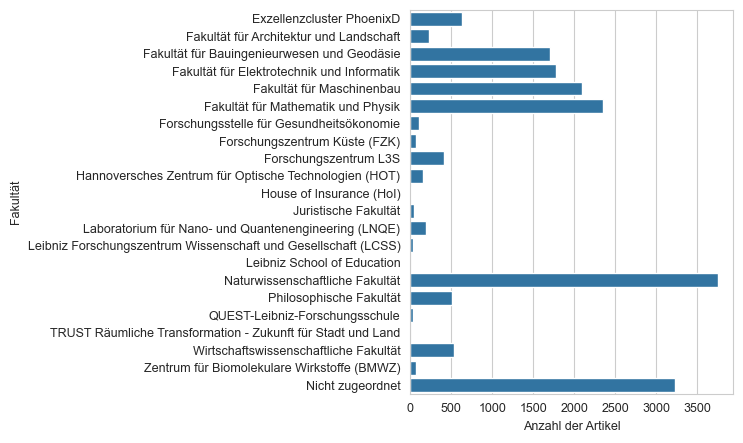

In [460]:
df_plot = df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7.5, 4.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='fak_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [461]:
df_plot[df_plot.fak_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.8202228412256267

In [200]:
MAPPING_DICT_DEPT = {
    'Fakultät für Architektur und Landschaft': {
        #'Forum für GenderKompetenz in Architektur Landschaft Planung': [],
        'Institut für Berufswissenschaften im Bauwesen (IBW)': ['berufswissenschaften'],
        'Institut für Entwerfen und Gebäudelehre': ['gebäudelehre'],
        'Institut für Entwerfen und Konstruieren (IEK)': ['design and (building|construction)', 'sustainable building systems'],
        'Institut für Entwerfen und Städtebau (IES)': ['urban design'],
        'Institut für Freiraumentwicklung': ['open space planning'],
        'Institut für Geschichte und Theorie der Architektur': ['institut für geschichte'],
        'Institut für Gestaltung und Darstellung': ['gestaltung und darstellung'],
        'Institut für Landschaftsarchitektur (ILA)': ['landscape architecture'],
        'Institut für Umweltplanung': ['environmental planning', 'umweltplanung'],
    },
    'Fakultät für Bauingenieurwesen und Geodäsie': {
        'Geodätisches Institut': ['geodetic institute'],
        'Institut für Baumanagement und Digitales Bauen': ['baumanagement', 'construction management'],
        'Institut für Baumechanik und Numerische Mechanik (IBNM)': ['numerische mechanik', '(computational|numerical) mechanics'],
        'Institut für Bauphysik': ['bauphysik', 'building physics'],
        'Institut für Baustoffe': ['building(s)? material', 'baustoffe'],
        'Institut für Erdmessung': ['erdmessung', 'geodesy'],
        'Institut für Geotechnik': ['geotechnik', 'geotechnical engineering'],
        'Institut für Hydrologie und Wasserwirtschaft': ['hydrology'],
        'Institut für Kartographie und Geoinformatik': ['(k|c)artograph(ie|y)'],
        'Institut für Massivbau': ['massivbau', 'concrete (structures|construction)'],
        'Institut für Photogrammetrie und GeoInformation (IPI)': ['photogrammetr(ie|(i)?y)'],
        'Institut für Risiko und Zuverlässigkeit': ['risk and reliability', 'institut(e)? (for|für) ris(iko|k)'],
        'Institut für Siedlungswasserwirtschaft und Abfalltechnik': ['siedlungswasserwirtschaft', 'waste management'],
        'Institut für Stahlbau': ['stahlbau', 'steel construction', 'institute of steel'],
        'Institut für Statik und Dynamik': ['statik und dynamik'],
        'Institut für Strömungsmechanik und Umweltphysik im Bauwesen': ['strömungsmechanik', 'fluid (mechanics|dynamics)', 'umweltphysik'],
        'Institut für Windenergiesysteme': ['wind energy'],
        'Ludwig-Franzius-Institut für Wasserbau, Ästuar- und Küsteningenieurwesen': ['ludwig(-|‐|\s)franzius'],
    },
    'Fakultät für Elektrotechnik und Informatik': {
        'Fachgruppe Didaktik der Elektrotechnik und Informatik': ['dida(k|c)ti(k|cs)', 'dei,'],
        'Institut für Antriebssysteme und Leistungselektronik': ['drive systems', 'antriebssysteme'],
        'Institut für Data Science': ['data science', 'knowledge-based'],
        'Institut für Elektrische Energiesysteme (IfES)': ['electric(al)? (power|energy)', 'schering', 'power electronics'],
        'Institut für Elektroprozesstechnik (ETP)': ['electrotechnology'],
        'Institut für Grundlagen der Elektrotechnik und Messtechnik': ['measurement', 'messtechnik'],
        'Institut für Hochfrequenztechnik und Funksysteme': ['mic(ro|or)wave'],
        'Institut für Informationsverarbeitung': ['information processing', 'informationsverarbeitung'],
        'Institut für Kommunikationstechnik': ['kommunikationstechnik', 'communication(s)? technology'],
        'Institut für Künstliche Intelligenz': ['artificial intelligence', 'natural language'],
        'Institut für Materialien und Bauelemente der Elektronik': ['electronic materials', 'materials and devices'],
        'Institut für Mensch-Maschine-Kommunikation': ['software engineering', 'human(-|\s)computer(-|\s)interaction'],
        'Institut für Mikroelektronische Systeme (IMS)': ['microele(c)?tronic'],
        'Institut für praktische Informatik': ['praktische informatik', 'practical computer science'],
        'Institut für Regelungstechnik (IRT)': ['regelungstechnik'],
        'Institut für Systems Engineering': ['systems engineering', 'scalable software'],
        'Institut für Theoretische Elektrotechnik': ['theoretische elektrotechnik'],
        'Institut für Theoretische Informatik': ['theoretische informatik', 'theoretical computer science'],
        'Laboratorium für Informationstechnologie (LFI)': ['informationstechnologie'],
    },
    'Fakultät für Maschinenbau': {
        'Fachgebiet Energie- und Verfahrenstechnik': ['continuum mechanics', 'turbomachinery', 'multiphase processes', 'thermodynami(k|cs)', 'technische verbrennung',
                                                      'technical combustion', 'power plant'
                                                     ],
        'Fachgebiet Kontruktion und Entwicklung': ['vibration research', 'tribolog(ie|y)', 'product development', 'mecha(n)?tronic system', 'kontinuumsmechanik',
                                                   'produktentwicklung', 'dynamics and vibrations'
                                                  ],
        'Institut für Berufswissenschaften der Metalltechnik': ['berufswissenschaften'],
        'Institut für Kunststoff- und Kreislauftechnik': ['plastics'],
        'Produktionstechnisches Zentrum Hannover (PZH)': ['fertigungstechnik', 'werkstoffkunde', 'fabrikanlagen', 'assembly', 'forming technolog(y|ies)', 'i(fw|wf),',
                                                          'production engineering', 'ins(t)?itute (of|for) transport', 'material(s)? science', 'automatisierungstechnik',
                                                          'transport technology', 'micro production', 'umformtechnik', 'mikroproduktionstechnik', 'metal forming'
                                                         ]
    },
    'Fakultät für Mathematik und Physik': {
        'Institut für Algebra, Zahlentheorie und Diskrete Mathematik (IAZD)': ['zahlentheorie', 'discrete mathematics', 'iazd,'],
        'Institut für Algebraische Geometrie': ['algebraische geometrie', 'algebraic geometry'],
        'Institut für Analysis': ['institut(e)? (of|for|für) analysis'],
        'Institut für Angewandte Mathematik': ['angewandte mathematik', 'applied mathematics'],
        'Institut für Didaktik der Mathematik und Physik': ['dida(k|c)ti(k|cs)'],
        'Institut für Differentialgeometrie': ['differentialgeometrie', 'differential geometry'],
        'Institut für Festkörperphysik': ['solid(-|‐|\s)state', 'festkörperphysik', 'solar energy'],
        'Institut für Gravitationsphysik': ['gravitationsphysik', 'gravitational physics'],
        'Institut für Meteorologie und Klimatologie': ['meteorolog(ie|y)'],
        'Institut für Photonik': ['photoni(k|c)', 'computational science'],
        'Institut für Quantenoptik': ['quantenoptik', 'quantum optics'],
        'Institut für Radioökologie und Strahlenschutz (IRS)': ['radioökologie', 'radioecology'],
        'Institut für Theoretische Physik': ['theoreti(sche|cal) physi(k|c)'],
        'Institut für Versicherungs- und Finanzmathematik': ['finanzmathematik', 'financial mathematics'],
        'Riemann Center for Geometry and Physics': ['riemann center'], # selbst ergänzt
    },
    'Juristische Fakultät': {
        'Institut für Arbeits-, Unternehmens- und Sozialrecht': ['sozialrecht'],
        'Institut für Deutsches und Europäisches Privatrecht und Wirtschaftsrecht': ['wirtschaftsrecht'],
        'Institut für Internationales Recht': ['internationales recht'],
        'Institut für Prozess- und Anwaltsrecht (IPA)': ['anwaltsrecht'],
        'Institut für Rechtsinformatik': ['legal informatics', 'rechtsinformatik', 'intellectual property'],
        'Institut für Staatswissenschaft': ['political science'],
        'Institut für Verwaltungsrecht': ['verwaltungsrecht'],
        'Kriminalwissenschaftliches Institut': ['kriminalwissenschaftliches institut'],
        'Lehrstuhl für Bürgerliches Recht und Versicherungsrecht': ['versicherungsrecht'],
        'Lehrstuhl für Öffentliches Recht mit einem internationalen Schwerpunkt': ['öffentliches recht'],
    },
    'Naturwissenschaftliche Fakultät': {
        'Institut für Anorganische Chemie': ['anorganische chemie', 'inorganic chemistry'],
        'Institut für Biostatistik': ['biostatisti(k|cs)'],
        'Institut für Botanik': ['botan(ik|y)'],
        'Institut für Didaktik der Naturwissenschaften': ['dida(k|c)ti(k|cs)', 'education'],
        'Institut für Erdsystemwissenschaften': ['soil (science|system)', 'earth system', 'erdsystemwissenschaften'],
        'Institut für Gartenbauliche Produktionssysteme': ['phytomedicine', 'horticultur', 'gartenbau', 'vegetable'],
        'Institut für Geobotanik': ['geobotanik'],
        'Institut für Geologie': ['geolog(ie|y)'],
        'Institut für Koordinationschemie': ['koordinationschemie', 'coordination chemistry'], #selbst ergänzt
        'Institut für Lebensmittelchemie': ['lebensmittel(chemie|wissenschaft)', 'food (chemistry|science)'],
        'Institut für Mikrobiologie (ifmb)': ['mi(k|c)robiolog(ie|y)'],
        'Institut für Mineralogie': ['mineralog(ie|y)'],
        'Institut für Organische Chemie': ['(?<!in)organic chemistry', '(?<!an)organische chemie'],
        'Institut für Pflanzenernährung': ['pflanzenernährung', 'nutrition'],
        'Institut für Pflanzengenetik': ['pflanzengenetik', 'plant genetic'],
        'Institut für Physikalische Chemie und Elektrochemie': ['ele(k|c)trochemi(e|stry)', 'physi(kalische|cal) chemi(e|stry)'],
        'Institut für Physische Geographie und Landschaftsökologie': ['landschaftsökologie', 'landscape ecology'],
        'Institut für Technische Chemie': ['(techni(sche|cal)|theoreti(sche|cal)) chemi(e|stry)'],
        'Institut für Wirtschafts- und Kulturgeographie': ['kulturgeographie', '(cultural|social) geography'],
        'Institut für Zellbiologie und Biophysik': ['biophysi(k|c)', 'cell biology', 'zellbiologie'],
        'Institute of Food and One Health (FOH)': ['one health'],
    }, 
    'Philosophische Fakultät': {
        'Deutsches Seminar': ['deutsches seminar'],
        'Englisches Seminar': ['english department', 'englisches seminar', 'department of english'],
        'Historisches Seminar': ['histor(isch|ical|y)'],
        'Institut für Berufspädagogik und Erwachsenenbildung': ['pädagogik', 'adult education'],
        'Institut für Didaktik der Demokratie': ['didaktik der demokratie'],
        'Institut für Erziehungswissenschaft': ['institute of education'],
        'Institut für Gestaltungspraxis und Kunstwissenschaft': ['kunstwissenschaft'],
        'Institut für Philosophie': ['philosoph(ie|y)'],
        'Institut für Politikwissenschaft': ['political science'],
        'Institut für Psychologie': ['psycholog(ie|y)'],
        'Institut für Religionswissenschaft': ['religion'],
        'Institut für Sonderpädagogik': ['special education', 'sonderpädagogik', 'inclusive education'],
        'Institut für Soziologie': ['so(z|c)iolog(ie|y)'],
        'Institut für Sportwissenschaft': ['sport(s)? science', 'sportwissenschaft'],
        'Institut für Theologie': ['theolog(ie|y)'],
        'Romanisches Seminar': ['romanisches seminar'],
        'Centre for Ethics and Law in the Life Sciences': ['cent(re|er) for ethics', 'cells'], #selbst ergänzt
    },
    'Wirtschaftswissenschaftliche Fakultät': {
        'Institut für Arbeitsökonomik': ['labo(u)?r economics', 'arbeitsökonomik'],
        'Institut für Banken und Finanzierung': ['banking'],
        'Institut für Betriebswirtschaftliche Steuerlehre': ['business taxation'],
        'Institut für Controlling': ['controlling'],
        'Institut für Empirische Wirtschaftsforschung': ['wirtschaftsforschung'],
        'Institut für Entwicklungs- und Agrarökonomik': ['agricultural economics'],
        'Institut für Finanzwirtschaft und Rohstoffmärkte': ['rohstoffmärkte'],
        'Institut für Geld und Internationale Finanzwirtschaft': ['internationale finanzwirtschaft'],
        'Institut für Gesundheitsökonomie (IHE)': ['health economics'],
        'Institut für Innovationsökonomik': ['innovation research', 'innovation management'],
        'Institut für interdisziplinäre Arbeitswissenschaft': ['employment studies', 'interdisziplinäre arbeitswissenschaft'],
        'Institut für Makroökonomik': ['macroeconomics'],
        'Institut für Marketing und Management': ['marketing'],
        'Institut für Mikroökonomik': ['microeconomics'],
        'Institut für Personal und Arbeit': ['personal und arbeit'],
        'Institut für Produktionswirtschaft': ['production management', 'produktionswirtschaft'],
        'Institut für Rechnungslegung und Wirtschaftsprüfung': ['accounting'],
        'Institut für Statistik': ['statisti(k|cs)'],
        'Institut für Umweltökonomik und Welthandel': ['environmental economics', 'welthandel'],
        'Institut für Unternehmensführung und Organisation': ['management (und|and) organi(s|z)ation'],
        'Institut für Versicherungsbetriebslehre': ['risk and insurance', 'versicherungsbetriebslehre'],
        'Institut für Wirtschaftsinformatik': ['information systems', 'wirtschaftsinformatik'],
        'Institut für Wirtschaftspolitik': ['economic policy', 'wirtschaftspolitik'],
        'Institut für Öffentliche Finanzen': ['öffentliche finanzen'],
        'Institut für Ökonometrie und Data Science': ['data science'],
    }
}

In [201]:
with open('./mapping_tables_dept/leibniz.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT_DEPT, f, ensure_ascii=False)

In [202]:
def map_dept(address: str, faculty: str) -> Union[str, None]:
    if faculty in MAPPING_DICT_DEPT:
        for k, v in MAPPING_DICT_DEPT.get(faculty).items():
            pattern = re.compile(r'|'.join(v), re.IGNORECASE)
            res = bool(pattern.search(address))
            if res:
                return k
        return None
    else:
        return None

In [203]:
df_with_inst.loc[df_with_inst['fak_name'] == 'Wirtschaftswissenschaftliche Fakultät', 'dept_name'] = \
    df_with_inst.loc[df_with_inst['fak_name'] == 'Wirtschaftswissenschaftliche Fakultät']['raw_affiliation_string'].apply(map_dept, 
                                                                                    faculty='Wirtschaftswissenschaftliche Fakultät')

In [204]:
df_with_inst[(df_with_inst['fak_name'] == 'Wirtschaftswissenschaftliche Fakultät') & df_with_inst['dept_name'].isnull()].raw_affiliation_string.unique()[:20]

array(['Leibniz  Universität Hannover - Institute of Economics',
       'Leibniz  Universität Hannover - Faculty of Economics and Management',
       'Leibniz University Hannover, Faculty of Economics and Management, Königsworther Platz 1, 30167 Hannover, Germany',
       'Leibniz Universität Hannover - Faculty of Economics and Management',
       'School of Economics and Management, Leibniz University Hannover, Hannover, Germany',
       'School of Economics and Management, Leibniz University Hannover, Koenigsworther Platz 1, 30167 Hannover, Germany',
       'Leibniz University Hannover, School of Economics and Management, Königsworther Platz 1, 30167 Hannover, Germany',
       'School of Economics and Management, Leibniz University Hannover, 30167 Hannover, Germany;',
       'Leibniz University Hannover, School of Economics and Management, Koenigsworther Platz 1, 30167 Hannover, Germany',
       'Leibniz University Hannover, Faculty of Economics and Management',
       'Leibniz Unive

In [205]:
df_with_inst[df_with_inst['fak_name'] == 'Wirtschaftswissenschaftliche Fakultät'].groupby(['dept_name'], dropna=False)['openalex_id'].count().reset_index()

,dept_name,openalex_id
0,Institut für Arbeitsökonomik,18
1,Institut für Banken und Finanzierung,6
2,Institut für Betriebswirtschaftliche Steuerlehre,3
3,Institut für Entwicklungs- und Agrarökonomik,26
4,Institut für Gesundheitsökonomie (IHE),15
5,Institut für Innovationsökonomik,13
6,Institut für Makroökonomik,8
7,Institut für Marketing und Management,27
8,Institut für Mikroökonomik,1
9,Institut für Personal und Arbeit,1


In [206]:
df_with_inst[df_with_inst['fak_name'] == 'Wirtschaftswissenschaftliche Fakultät']

,fak_name,parent_name,raw_affiliation_string,openalex_id,dept_name
4,Wirtschaftswissenschaftliche Fakultät,Gottfried Wilhelm Leibniz Universität Hannover,Leibniz Universität Hannover - Institute of E...,https://openalex.org/W4312493720,None
33,Wirtschaftswissenschaftliche Fakultät,Gottfried Wilhelm Leibniz Universität Hannover,Leibniz Universität Hannover - Faculty of Eco...,https://openalex.org/W4312639876,None
83,Wirtschaftswissenschaftliche Fakultät,Gottfried Wilhelm Leibniz Universität Hannover,"Leibniz University Hannover, Faculty of Econom...",https://openalex.org/W4206374009,None
118,Wirtschaftswissenschaftliche Fakultät,Gottfried Wilhelm Leibniz Universität Hannover,"Information Systems Institute, Leibniz Univers...",https://openalex.org/W4286696770,Institut für Wirtschaftsinformatik
182,Wirtschaftswissenschaftliche Fakultät,Gottfried Wilhelm Leibniz Universität Hannover,Institute for Environmental Economics and Worl...,https://openalex.org/W4281558441,Institut für Umweltökonomik und Welthandel
...,...,...,...,...,...
16445,Wirtschaftswissenschaftliche Fakultät,Gottfried Wilhelm Leibniz Universität Hannover,Leibniz Universität Hannover - Faculty of Eco...,https://openalex.org/W4235675006,None
16460,Wirtschaftswissenschaftliche Fakultät,Gottfried Wilhelm Leibniz Universität Hannover,Leibniz University Hannover and Centre for App...,https://openalex.org/W4408359466,None
16511,Wirtschaftswissenschaftliche Fakultät,Gottfried Wilhelm Leibniz Universität Hannover,Institute for Environmental Economics and Worl...,https://openalex.org/W3126918528,Institut für Umweltökonomik und Welthandel
16523,Wirtschaftswissenschaftliche Fakultät,Gottfried Wilhelm Leibniz Universität Hannover,Leibniz Universität Hannover - Faculty of Eco...,https://openalex.org/W3027096539,None
